# Kompresija slika

## Skup podataka
Opisati slike koje se koriste; za svaki metod naci specificnosti

In [19]:
import numpy as np
from matplotlib import pyplot as plt
from numpy import linalg as LA
import pywt
import cv2
import math

def plot_comparison(original, reconstructed, method_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off') 
    
    # Right subplot: Reconstructed
    axes[1].imshow(reconstructed, cmap='gray')
    axes[1].set_title(f'{method_name}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

## Metode
Za svaku metodu kratka teorija + pajton kod 

### 1. SVD

#### Teorijske osnove

#### Primena

###  2. DWT

#### Teorijske osnove

#### Primena

### 3. JPEG-DCT

JPEG (Joint Photographic Experts Group) je standardizovani algoritam za kompresiju slika sa gubitkom.

#### Arhitektura procesa kompresije:
1. Kolor konverzija(RGB ili drugog modela u YCbCr)
2. Diskretna kosinusna transformacija
3. Kvantizacija
4. Cik-Cak skeniranje i Hafmanovo kodiranje(kompresija bez gubitka)

#### 1. Kolor konverzija (RGB u YCbCr)
Ljudsko oko primećuje promene u osvetljenju bolje nego promene u nijansama boja. Zbog toga se RGB prostor prevodi u YCbCr domen pomoću sledeće transformacione matrice:

$$\begin{bmatrix} Y \\ Cb \\ Cr \end{bmatrix} = \begin{bmatrix} 0 & 0.299 & 0.587 & 0.114 \\ 0 & -0.168736 & -0.331264 & 0.5 \\ 0 & 0.5 & -0.418688 & -0.081312 \end{bmatrix} \begin{bmatrix} R \\ G \\ B \end{bmatrix} + \begin{bmatrix} 0 \\ 128 \\ 128 \end{bmatrix}$$

> **Napomena:** Svi naredni koraci izvršavaju se potpuno nezavisno i paralelno nad svakim kanalom ($Y$, $Cb$ i $Cr$).

#### 2. Dvodimenzionalna DCT-II Transformacija
Slika se deli na nezavisne blokove dimenzija $8 \times 8$ piksela. Nad svakim, prethodno centriranim blokom (oduzimanjem vrednosti 128), primenjuje se dvodimenzionalna diskretna kosinusna transformacija koja prostorne intenzitete piksela prevodi u koeficijente prostornih frekvencija:

$$DCT(u, v) = \frac{1}{4} C(u) C(v) \sum_{x=0}^{7} \sum_{y=0}^{7} f(x, y) \cos\left[\frac{(2x + 1)u\pi}{16}\right] \cos\left[\frac{(2y + 1)v\pi}{16}\right]$$

Gde su $f(x, y)$ vrednosti prostornih piksela unutar bloka, a $C(u)$ i $C(v)$ definisani kao:

$$C(\xi) = \begin{cases} \frac{1}{\sqrt{2}}, & \text{za } \xi = 0 \\ 1, & \text{za } \xi > 0 \end{cases}$$

Koeficijent u gornjem levom uglu ($DCT(0,0)$) predstavlja **DC komponentu** (srednju vrednost osvetljenja bloka), dok ostala 63 elementa predstavljaju **AC komponente** viših frekvencija.

#### 3. Kvantizacija 
Kompresija sa gubitkom se zapravo odigrava u koraku kvantizacije. Frekvencijski koeficijenti svakog bloka unutar svakog kanala se dele elementima matrice kvantizacije $Q$ i zaokružuju na cele brojeve. Za kanal osvetljenosti ($Y$) koristi se matrica $Q_Y$, dok se za kanale boja ($Cb, Cr$) koristi agresivnija hrominantna matrica $Q_C$.

$$C(u, v) = \text{round}\left(\frac{DCT(u, v)}{Q(u, v)}\right)$$

Ovaj korak pretvara većinu AC koeficijenata visokih frekvencija (u donjem desnom delu matrice) u nule, čime se eliminišu vizuelno manje bitni detalji i postiže glavni faktor kompresije.

#### 4. Entropijsko kodiranje
Nakon kvantizacije, nad preostalim koeficijentima se vrši finalna kompresija bez gubitka (entropijsko kodiranje kroz RLE i Hafmanov algoritam). Za potrebe ovog projekta, gde je fokus na upoređivanju različitih tehnika kompresije sa gubitkom u frekvencijskom domenu, nećemo dublje ulaziti u detalje samog entropijskog kodiranja.

#### Rekonstrukcija slike (Inverzni proces)
Proces dekompresije počinje dekvantizacijom gde se rekonstruišu približni frekvencijski koeficijenti: $R(u, v) = C(u, v) \times Q(u, v)$. Nakon toga, primenjuje se inverzna diskretna kosinusna transformacija (2D IDCT) kako bi se podaci vratili u prostorni domen piksela, uz poništavanje početnog centriranja:

$$f'(x, y) = \text{IDCT}(R(u, v)) + 128$$

#### Primena

JPEG zasnovan na DCT-u je postao industrijski standard zahvaljujući svojoj računskoj jednostavnosti, izuzetnoj hardverskoj podršci i zadovoljavajućim performansama pri umerenim stepenima kompresije.

Međutim, algoritam pati od jednog fundamentalnog nedostatka:

* **Problem blok-artefakata (Blocking Artifacts):** Pošto se slika striktno deli na izolovane $8 \times 8$ blokove, korelacija i kontinuitet signala preko granica tih blokova bivaju potpuno ignorisani. Pri višim stepenima kompresije (kada matrica kvantizacije "ogoli" podatke), granice blokova postaju oštre i vidljive ljudskom oku.

Pokušaji rešavanja ovog problema, poput Lapped Orthogonal Transforms (LOT) koji koriste glatko preklapanje blokova, drastično povećavaju računarsku kompleksnost, što u praksi nije opravdalo masovnu zamenu standardnog DCT-a. To otvara prostor za **Talasiće (DWT)** koji ne dele početnu sliku na blokove.

*TODO: mozda prebaciti implementaciju na 3 kanala*

In [7]:
def jpeg_compression(img,Q):
    img= np.float32(img)-128
    
    block_size=8
    h,w= img.shape
    nbh= math.ceil(h/block_size)
    nbw= math.ceil(w/block_size)
    H,W= nbh*block_size, nbw*block_size
    padded_img= np.zeros((H,W), dtype= np.float32)
    padded_img[0:h,0:w]= img
    
    print(f'Before padding:{img.shape}')
    print(f'After padding:{padded_img.shape}')
    
    #forward_dct
    dct_coef= np.zeros((H,W),dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)* block_size
        for j in range(nbw):
            w1,w2= j* block_size,(j+1)*block_size
            block= padded_img[h1:h2,w1:w2]
            dct_coef[h1:h2,w1:w2]= cv2.dct(block)
    
    
    #quantization
    quantized_matrix= np.zeros((H,W),dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)* block_size
        for j in range(nbw):
            w1,w2= j* block_size,(j+1)*block_size
            quantized_matrix[h1:h2,w1:w2]= np.around(dct_coef[h1:h2,w1:w2]/QTY)

    return quantized_matrix

def jpeg_decompress(quantized_img,Q):
    block_size=8
    H,W= quantized_img.shape
    nbh,nbw= H//block_size,W//block_size
    
    #dequantization
    dequantized_coef= np.zeros((H, W), dtype=np.float32)
    for i in range(nbh):
        h1,h2= i*block_size, (i+1)* block_size
        for j in range(nbw):
            w1,w2= j* block_size,(j+1)*block_size
            dequantized_coef[h1:h2,w1:w2]= quantized_img[h1:h2,w1:w2]*Q
                
    
    #inverse_dct 
    reconstruct_img= np.zeros((H,W), dtype=np.float32)
    for i in range(nbh):
        for i in range(nbh):
            h1,h2= i*block_size, (i+1)* block_size
            for j in range(nbw):
                w1,w2= j* block_size,(j+1)*block_size
                
                reconstruct_img[h1:h2,w1:w2]= cv2.idct(dequantized_coef[h1:h2,w1:w2])+128.0
                
    #todo: do i need to clip padded part?
    
    return np.int32(reconstruct_img)
    


Before padding:(625, 1000)
After padding:(632, 1000)


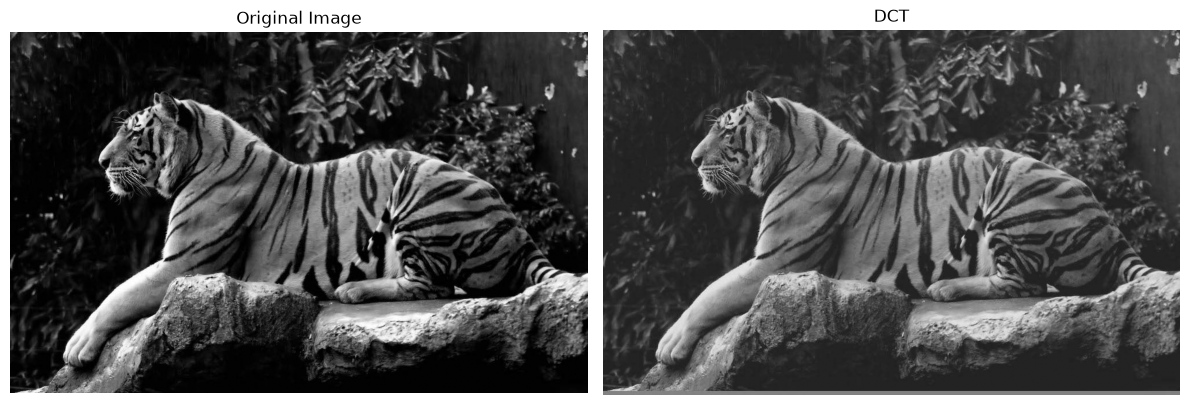

In [8]:
# define quantization tables
#for now only using first table
QTY = np.array([[16, 11, 10, 16, 24, 40, 51, 61],  # luminance quantization table
                [12, 12, 14, 19, 26, 48, 60, 55],
                [14, 13, 16, 24, 40, 57, 69, 56],
                [14, 17, 22, 29, 51, 87, 80, 62],
                [18, 22, 37, 56, 68, 109, 103, 77],
                [24, 35, 55, 64, 81, 104, 113, 92],
                [49, 64, 78, 87, 103, 121, 120, 101],
                [72, 92, 95, 98, 112, 100, 103, 99]])

QTC = np.array([[17, 18, 24, 47, 99, 99, 99, 99],  # chrominance quantization table
                [18, 21, 26, 66, 99, 99, 99, 99],
                [24, 26, 56, 99, 99, 99, 99, 99],
                [47, 66, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99],
                [99, 99, 99, 99, 99, 99, 99, 99]])


#example
img= cv2.imread('data/tiger.jpg',cv2.IMREAD_GRAYSCALE)
q_img=jpeg_compression(img,QTY)
rec_img=jpeg_decompress(q_img,QTY)
plot_comparison(img,rec_img,"DCT")

### 4. Hibrid SVD i DWT

#### Teorijske osnove

#### Primena

In [32]:
def svd_compression(image, r):
    U, S, VT = LA.svd(image)
    
    Ur = U[:, :r]
    Sr = np.diag(S[:r])
    VTr = VT[:r, :]
    
    comp_img = np.dot(np.dot(Ur, Sr), VTr)
    #plot_comparison(image,comp_img,f'svd with {r} sv')
    return comp_img

#base dwt
def dwt_compression(img, wavelet, mode, level, compression_level):
    coef= pywt.wavedec2(img,wavelet, mode,level)

    arr,slices= pywt.coeffs_to_array(coef)
    threash_index= int(arr.size*(1-compression_level))
    threash=  np.sort(abs((arr.ravel())))[threash_index]
    arr_compr= arr* (abs(arr)> threash)
    
    return arr_compr,slices
 
#
def dwt_decompression(img_comp, slices, wavelet, mode,level):
    coef = pywt.array_to_coeffs(img_comp, slices, output_format="wavedecn")
    reconstructed = pywt.waverecn(coef, wavelet=wavelet, mode=mode)
    return reconstructed


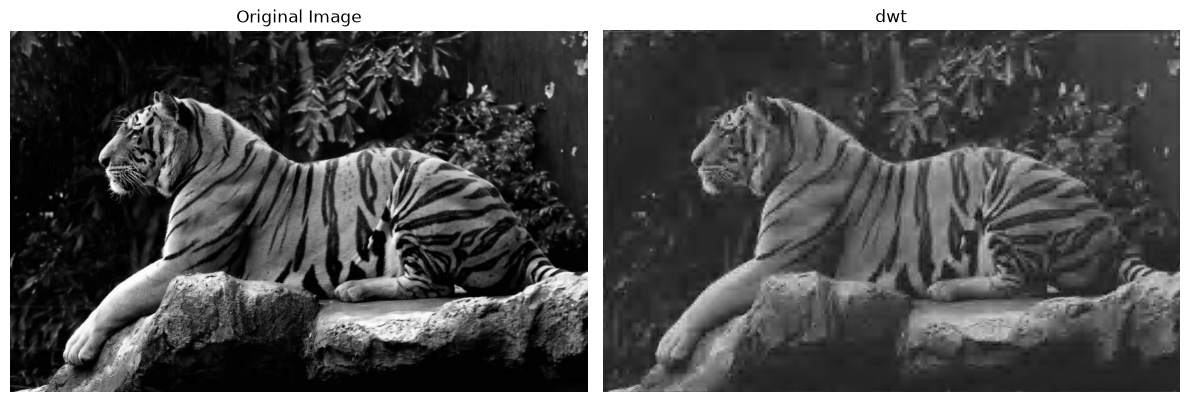

In [38]:
#rec_img= svd_compression(img,100)

wavelet='db2'  #(used in hybrid)
mode='periodization'
level=5
compression_level= 0.8  #80% used in dwt 

comp_img,slices=dwt_compression(img, wavelet, mode, level, compression_level)
rec_img= dwt_decompression(comp_img, slices, wavelet, mode,level)
plot_comparison(img,reconstructed,'dwt')

In [47]:
def svd_dwt_compression(img,rank_svd=50,level_dwt=5,mode_dwt='periodization',wavelet='db2',compression_level=0.8):
    img_svd= svd_compression(img,rank_svd)
    comp_img, slices=dwt_compression(img_svd, wavelet, mode_dwt, level_dwt, compression_level)
    
    return comp_img,slices

def svd_dwt_decompression(img,slices,level_dwt=5, mode_dwt='periodization',wavelet='db2'):
    return dwt_decompression(comp_img,slices, wavelet, mode_dwt, level)


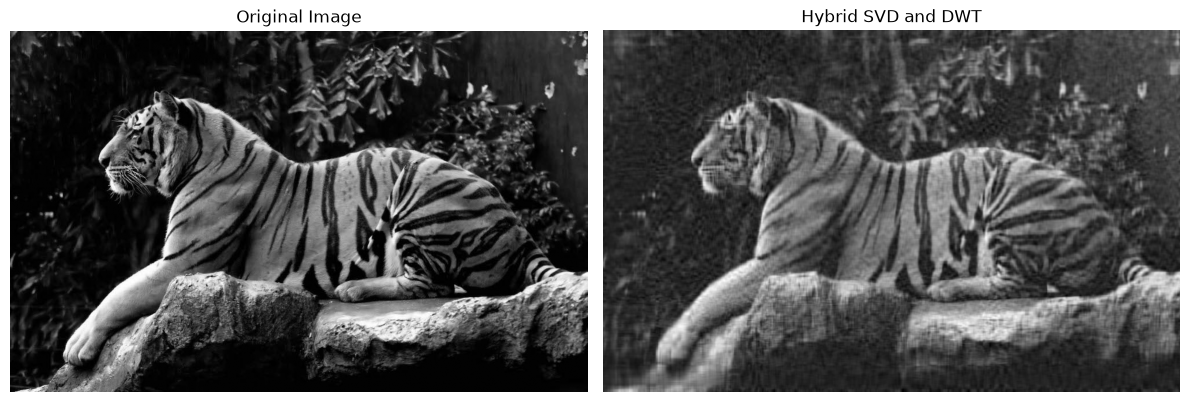

In [48]:
#ex.Hybrid SVD and DWT

comp_img,slices= svd_dwt_compression(img)

rec_img= svd_dwt_decompression(comp_img,slices)

plot_comparison(img, rec_img,"Hybrid SVD and DWT")

## Poredjenje modela

### Metrike
Pomeni:
- PSNR
- MSE
- SSI

### Poredjenje
Grafici, vizuelni prikaz itd

## Zakljucak